In [1]:
import struct
import pandas as pd
import pyodbc
from azure.identity import InteractiveBrowserCredential
tenant_id = "****************"

# 1. Fetch Azure Entra ID Access Token 
credential = InteractiveBrowserCredential(tenant_id=tenant_id)
token_bytes = credential.get_token(
    "https://database.windows.net/.default"
).token.encode("utf-16-le")
token_struct = struct.pack(f"<I{len(token_bytes)}s", len(token_bytes), token_bytes)

# 2. Synapse Endpoint Details
server = "awcryptoproject-ondemand.sql.azuresynapse.net"
database = "GoldAnalytics"
driver = "{ODBC Driver 18 for SQL Server}"

conn_str = (
    f"DRIVER={driver};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Encrypt=yes;"
    f"TrustServerCertificate=yes;"
)

# 3. Connect using Access Token (SQL_COPT_SS_ACCESS_TOKEN = 1256)
SQL_COPT_SS_ACCESS_TOKEN = 1256
conn = pyodbc.connect(conn_str, attrs_before={SQL_COPT_SS_ACCESS_TOKEN: token_struct})

C:\miniconda3\Lib\site-packages\msal\oauth2cli\oauth2.py:453: UserWarning: response_mode='form_post' is recommended for better security. See https://www.rfc-editor.org/rfc/rfc9700.html#section-4.3.1
  warnings.warn(


In [2]:
dim_crypto_assets = "SELECT * FROM dim_crypto_assets;"
df_crypto_assets = pd.read_sql(dim_crypto_assets, conn)

# Display Data
df_crypto_assets.head()

C:\Users\QC#\AppData\Local\Temp\ipykernel_15928\486631647.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_crypto_assets = pd.read_sql(dim_crypto_assets, conn)


,crypto_name,first_trade_timestamp,latest_trade_timestamp,total_lifetime_ticks,all_time_low_price_usd,all_time_high_price_usd,lifetime_avg_price_usd,historical_lifetime_ticks,streaming_lifetime_tick
0,bitcoin,2025-01-01 00:00:00.648204,2026-08-16 06:59:56,34919249,62547.0,109588.0,100274.51,34917089,2160


In [3]:
fct_crypto_hourly_metrics = "SELECT * FROM fct_crypto_hourly_metrics;"
df_fct_crypto_hourly_metrics = pd.read_sql(fct_crypto_hourly_metrics, conn)

# Display Data
df_fct_crypto_hourly_metrics.head()

C:\Users\QC#\AppData\Local\Temp\ipykernel_15928\3402531348.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_fct_crypto_hourly_metrics = pd.read_sql(fct_crypto_hourly_metrics, conn)


,trade_hour,crypto_name,open_price_usd,high_price_usd,low_price_usd,close_price_usd,avg_price_usd,hourly_price_spread_usd,hourly_price_change_usd,price_change_pct,total_volume_crypto,total_volume_usd,total_ticks_count,historical_ticks_count,streaming_ticks_count,buyer_maker_trades_count,seller_maker_trades_count
0,2026-08-16 06:00:00,bitcoin,63012.0,63024.0,62994.0,63014.0,63011.80,30.0,2.0,0.00,0.0,0.0,30,0,30,0,0
1,2026-08-16 05:00:00,bitcoin,63041.0,63043.0,62997.0,63009.0,63021.87,46.0,-32.0,-0.05,0.0,0.0,30,0,30,0,0
2,2026-08-16 04:00:00,bitcoin,63070.0,63105.0,63041.0,63041.0,63078.27,64.0,-29.0,-0.05,0.0,0.0,30,0,30,0,0
3,2026-08-16 03:00:00,bitcoin,63068.0,63074.0,63065.0,63071.0,63069.60,9.0,3.0,0.00,0.0,0.0,30,0,30,0,0
4,2026-08-16 02:00:00,bitcoin,62999.0,63088.0,62969.0,63069.0,63036.87,119.0,70.0,0.11,0.0,0.0,30,0,30,0,0


In [4]:
df= pd.merge(df_fct_crypto_hourly_metrics, df_crypto_assets, on='crypto_name', how='inner')

In [5]:
df.isna().sum()

trade_hour                   0
crypto_name                  0
open_price_usd               0
high_price_usd               0
low_price_usd                0
close_price_usd              0
avg_price_usd                0
hourly_price_spread_usd      0
hourly_price_change_usd      0
price_change_pct             0
total_volume_crypto          0
total_volume_usd             0
total_ticks_count            0
historical_ticks_count       0
streaming_ticks_count        0
buyer_maker_trades_count     0
seller_maker_trades_count    0
first_trade_timestamp        0
latest_trade_timestamp       0
total_lifetime_ticks         0
all_time_low_price_usd       0
all_time_high_price_usd      0
lifetime_avg_price_usd       0
historical_lifetime_ticks    0
streaming_lifetime_tick      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Feature Engineering on Merged Dataframe (df)
df["order_imbalance_ratio"] = (
    df["buyer_maker_trades_count"] - df["seller_maker_trades_count"]
) / df["total_ticks_count"]
df["avg_trade_size_usd"] = df["total_volume_usd"] / df["total_ticks_count"]
df["lifetime_price_drift_pct"] = (
    (df["avg_price_usd"] - df["lifetime_avg_price_usd"])
    / df["lifetime_avg_price_usd"]
) * 100
df["normalized_volatility_pct"] = (
    df["hourly_price_spread_usd"] / df["lifetime_avg_price_usd"]
) * 100
df["streaming_pipeline_health"] = (
    df["streaming_ticks_count"] / df["total_ticks_count"]
)
df["vwap_usd"] = df["total_volume_usd"] / df["total_volume_crypto"]

In [8]:
df

,trade_hour,crypto_name,open_price_usd,high_price_usd,low_price_usd,close_price_usd,avg_price_usd,hourly_price_spread_usd,hourly_price_change_usd,price_change_pct,...,all_time_high_price_usd,lifetime_avg_price_usd,historical_lifetime_ticks,streaming_lifetime_tick,order_imbalance_ratio,avg_trade_size_usd,lifetime_price_drift_pct,normalized_volatility_pct,streaming_pipeline_health,vwap_usd
0,2026-08-16 06:00:00,bitcoin,63012.00,63024.00,62994.00,63014.00,63011.80,30.00,2.00,0.00,...,109588.0,100274.51,34917089,2160,0.000000,0.000000,-37.160700,0.029918,1.0,NaN
1,2026-08-16 05:00:00,bitcoin,63041.00,63043.00,62997.00,63009.00,63021.87,46.00,-32.00,-0.05,...,109588.0,100274.51,34917089,2160,0.000000,0.000000,-37.150658,0.045874,1.0,NaN
2,2026-08-16 04:00:00,bitcoin,63070.00,63105.00,63041.00,63041.00,63078.27,64.00,-29.00,-0.05,...,109588.0,100274.51,34917089,2160,0.000000,0.000000,-37.094412,0.063825,1.0,NaN
3,2026-08-16 03:00:00,bitcoin,63068.00,63074.00,63065.00,63071.00,63069.60,9.00,3.00,0.00,...,109588.0,100274.51,34917089,2160,0.000000,0.000000,-37.103058,0.008975,1.0,NaN
4,2026-08-16 02:00:00,bitcoin,62999.00,63088.00,62969.00,63069.00,63036.87,119.00,70.00,0.11,...,109588.0,100274.51,34917089,2160,0.000000,0.000000,-37.135699,0.118674,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,2025-01-01 04:00:00,bitcoin,93838.04,93838.04,93500.00,93553.91,93681.78,338.04,-284.13,-0.30,...,109588.0,100274.51,34917089,2160,0.136570,938.206640,-6.574682,0.337115,0.0,93670.338382
813,2025-01-01 03:00:00,bitcoin,94098.91,94098.91,93728.22,93838.04,93881.90,370.69,-260.87,-0.28,...,109588.0,100274.51,34917089,2160,0.027347,753.658203,-6.375110,0.369675,0.0,93887.107754
814,2025-01-01 02:00:00,bitcoin,93607.73,94105.12,93594.56,94098.91,93822.81,510.56,491.18,0.52,...,109588.0,100274.51,34917089,2160,-0.232529,697.629008,-6.434038,0.509162,0.0,93847.106673
815,2025-01-01 01:00:00,bitcoin,94401.13,94408.72,93578.77,93607.74,93938.63,829.95,-793.39,-0.84,...,109588.0,100274.51,34917089,2160,0.186525,1144.408047,-6.318535,0.827678,0.0,93931.046702


In [9]:
import pandas as pd
import numpy as np
import plotly.express as px

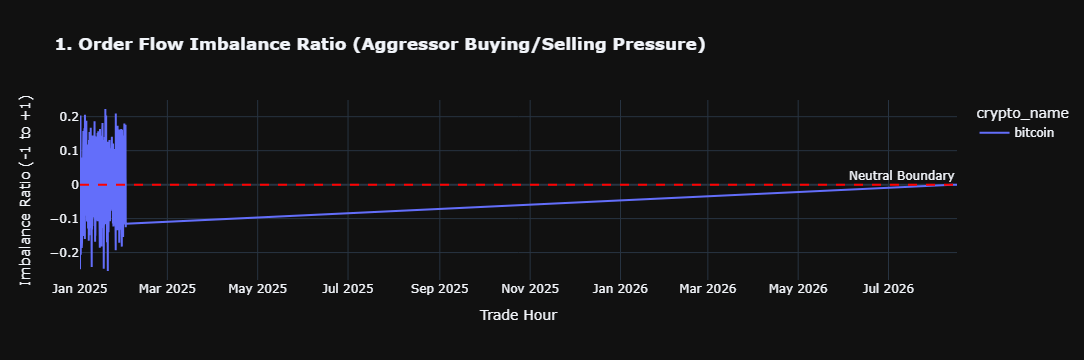

In [11]:
fig_order_flow_imbalance = px.line(
    df,
    x="trade_hour",
    y="order_imbalance_ratio",
    color="crypto_name",
    title="<b>1. Order Flow Imbalance Ratio (Aggressor Buying/Selling Pressure)</b>",
    labels={
        "order_imbalance_ratio": "Imbalance Ratio (-1 to +1)",
        "trade_hour": "Trade Hour",
    },
    template="plotly_dark",
)
fig_order_flow_imbalance.add_hline(
    y=0, line_dash="dash", line_color="red", annotation_text="Neutral Boundary"
)
fig_order_flow_imbalance.show()

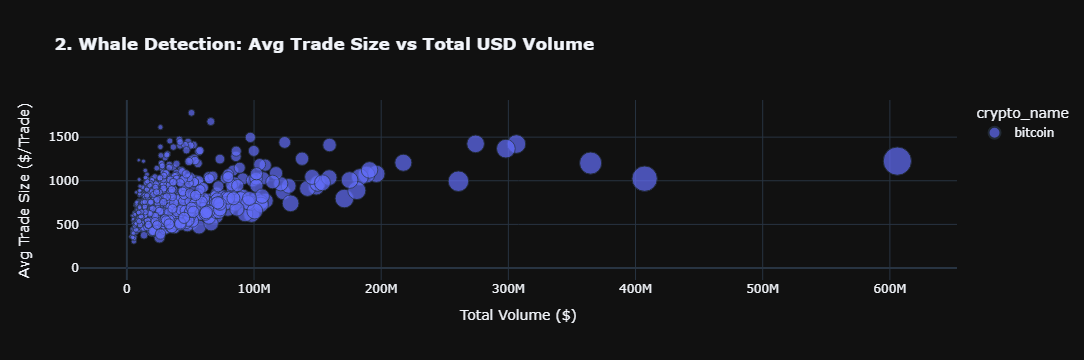

In [13]:
fig_whale_detection = px.scatter(
    df,
    x="total_volume_usd",
    y="avg_trade_size_usd",
    color="crypto_name",
    size="total_ticks_count",
    hover_data=["trade_hour", "avg_price_usd"],
    title="<b>2. Whale Detection: Avg Trade Size vs Total USD Volume</b>",
    labels={
        "avg_trade_size_usd": "Avg Trade Size ($/Trade)",
        "total_volume_usd": "Total Volume ($)",
    },
    template="plotly_dark",
)
fig_whale_detection.show()

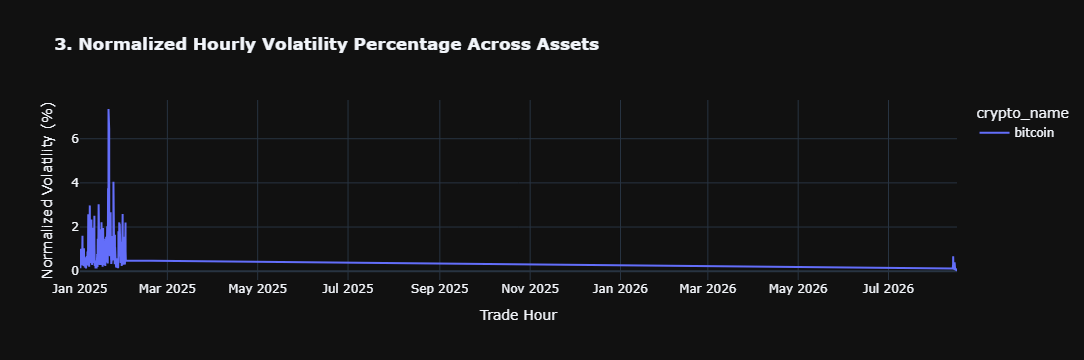

In [20]:
fig_normalized_hourly_volatility = px.line(
    df,
    x="trade_hour",
    y="normalized_volatility_pct",
    color="crypto_name",
    title="<b>3. Normalized Hourly Volatility Percentage Across Assets</b>",
    labels={
        "normalized_volatility_pct": "Normalized Volatility (%)",
        "trade_hour": "Trade Hour",
    },
    template="plotly_dark",
)

fig_normalized_hourly_volatility.show()

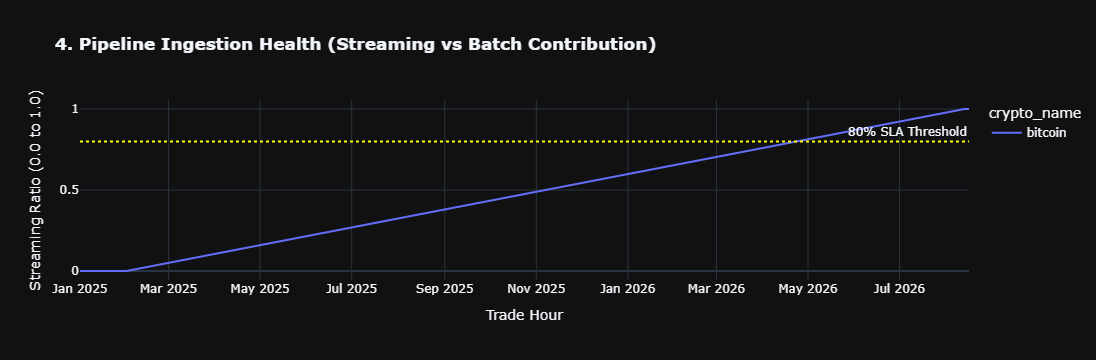

In [23]:
fig_pipeline_ingestion_health = px.line(
    df,
    x="trade_hour",
    y="streaming_pipeline_health",
    color="crypto_name",
    title="<b>4. Pipeline Ingestion Health (Streaming vs Batch Contribution)</b>",
    labels={
        "streaming_pipeline_health": "Streaming Ratio (0.0 to 1.0)",
        "trade_hour": "Trade Hour",
    },
    template="plotly_dark",
)

# 80% SLA Threshold Line
fig_pipeline_ingestion_health.add_hline(
    y=0.8,
    line_dash="dot",
    line_color="yellow",
    annotation_text="80% SLA Threshold",
)

fig_pipeline_ingestion_health.show()

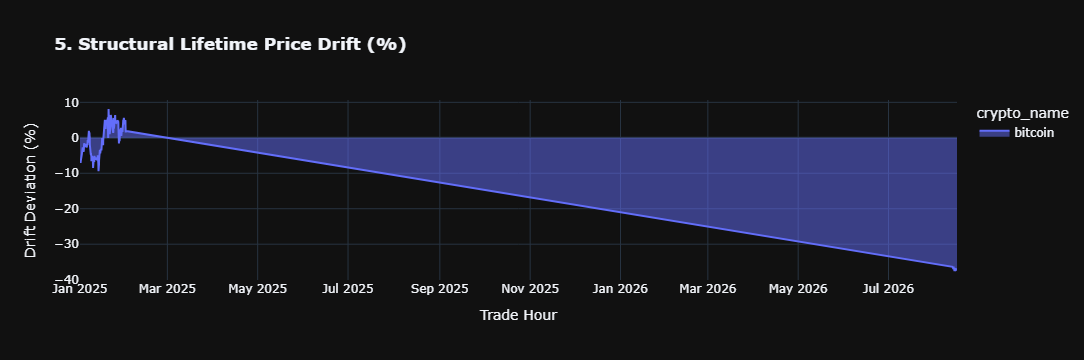

In [24]:
fig_str_p_d = px.area(
    df,
    x="trade_hour",
    y="lifetime_price_drift_pct",
    color="crypto_name",
    title="<b>5. Structural Lifetime Price Drift (%)</b>",
    labels={
        "lifetime_price_drift_pct": "Drift Deviation (%)",
        "trade_hour": "Trade Hour",
    },
    template="plotly_dark",
)

fig_str_p_d.show()